In [19]:
# step 1 import lib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix , classification_report

In [20]:
print("Tensorflow version = ",tf.__version__)

Tensorflow version =  2.19.0


In [21]:
# step 2 Load MNIST Dataset
(x_train , y_train) , (x_test , y_test) = keras.datasets.mnist.load_data()

print(f"Traning images shape = {x_train.shape}")
print(f"Traning labels shape = {y_train.shape}")
print(f"Testing images shape = {x_test.shape}")
print(f"Testing labels shape = {y_test.shape}")

Traning images shape = (60000, 28, 28)
Traning labels shape = (60000,)
Testing images shape = (10000, 28, 28)
Testing labels shape = (10000,)


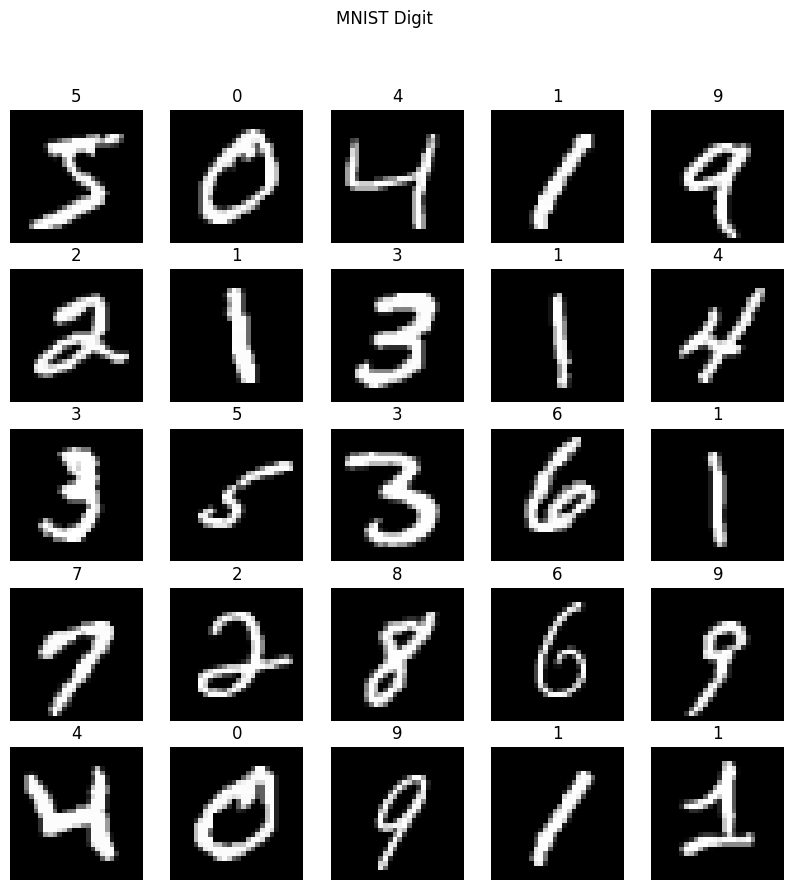

In [22]:
# Step 3  visualize sample image
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(x_train[i] , cmap="gray")
  plt.title(y_train[i])
  plt.axis("off")
plt.suptitle("MNIST Digit")
plt.show()

In [23]:
# step 4 Preprocess the data

# Reshape to add channel
# gray scal -> 1
# normalize to [0/1]

x_train = x_train.reshape(-1,28,28,1).astype('float32')/255.0
x_test = x_test.reshape(-1,28,28,1).astype('float32')/255

# One hot encode labels -> [0,0,0,1,0,0]
t_train_cat = keras.utils.to_categorical(y_train,10)
t_test_cat = keras.utils.to_categorical(y_test,10)

print("|- Preprocessed Data -|")

|- Preprocessed Data -|


In [25]:
# step 5 build CNN model
model = keras.Sequential([
    layers.Input(shape=(28,28,1)),

    # first convolutional block
    layers.Conv2D(32,kernel_size = (3,3),activation="relu"), # learn 32 filters
    layers.MaxPooling2D(pool_size=(2,2)),

    # second convolutional block
    layers.Conv2D(64,kernel_size = (3,3),activation="relu"), # learn 64 filters
    layers.MaxPooling2D(pool_size=(2,2)),

    # flatten and chassify
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),  # prevents overfitting
    layers.Dense(10,activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from IPython.core import history
# step 6 Complie and Train

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train , t_train_cat,
    batch_size=64,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 31s 35ms/step - accuracy: 0.9200 - loss: 0.2584 - val_accuracy: 0.9828 - val_loss: 0.0592
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9740 - loss: 0.0876 - val_accuracy: 0.9878 - val_loss: 0.0416
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.9803 - loss: 0.0645 - val_accuracy: 0.9895 - val_loss: 0.0381
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.9848 - loss: 0.0504 - val_accuracy: 0.9898 - val_loss: 0.0355
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9861 - loss: 0.0430 - val_accuracy: 0.9897 - val_loss: 0.0358
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.9890 - loss: 0.0376 - val_accuracy: 0.9913 - val_loss: 0.0297
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9901 - loss: 0.0304 - val_accuracy: 0.9912 - val_loss: 0.0352
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.9916 - loss: 0.0274 - 